# **It's Jaundice's World, and St. James Hospital is Just Living in It.**

### Authors:  Mariel Concepcion, Lorenzo De Villa, Bingbong Manglicmot, Caitlin Sebastian, JF Viray
### Learning Team: 7
---

# **1. Executive Summary**

Data Monitors created a machine learning model for St. James Hospital’s OB-GYN facility to classify newborns as either at risk or healthy. The system was meant to ease the burden of continuous monitoring and improve neonatal care. Our project takes on this case with two goals: first, to understand why the model failed so severely, and second, to design a stronger and more reliable replacement.
The failure had devastating consequences. In its thirtieth week of use, a newborn was misclassified as healthy and died without timely intervention. A review uncovered at least twelve other misclassifications, exposing systemic flaws. Trust in the algorithm collapsed, disrupting workflow and prompting the hospital to commission an independent audit. The central question became why the model failed and how it could be improved.

Our analysis showed that the model leaned too heavily on jaundice levels. Global explainability tools such as SHAP values, permutation importance, and model coefficients all ranked jaundice far above other features. Partial Dependence Plots confirmed this pattern. As jaundice increased, the probability of being labeled at risk rose above 70%, while heart rate and oxygen saturation peaked at only about 50% and 35%. Feature interaction analysis using Friedman’s H-statistic reinforced this conclusion, showing relatively weak dependencies. The H-statistic between jaundice and oxygen saturation was around 42%, and between jaundice and heart rate bpm around 34%. This indicated that jaundice acted mostly in isolation, which helps explain why the model focused on it so heavily.

Local methods supported the same conclusion. Anchors revealed that low jaundice alone could guarantee a healthy classification, with rules that reached 100% precision and coverage of about 75% to 80%. ICE plots showed a sigmoid pattern in which risk stayed low at first, then rose sharply with increasing jaundice until plateauing near 100%. LIME further showed that two otherwise similar babies could be classified differently based only on jaundice. While jaundice was clearly a powerful predictor, the model’s overreliance created blind spots that proved dangerous in practice.

To correct this, we developed a baseline Random Forest model that spread importance more evenly across features. The new model achieved an F1 score of 99.1% for at-risk babies and an overall F1 score of 99.8%. These results show that careful model design, combined with explainability, can produce both higher performance and greater reliability.


(The project environment is set up with Python version 3.12.8.)

---

# **2. Introduction** 
Data Monitors created a machine learning model for St. James Hospital’s OB-GYN facility with its purpose to classify newborns as either at risk or healthy with the broader goal of easing the burden of continuous monitoring on staff. A complicated occurred when the deployed model produced severe misclassifications. In its thirtieth week of use, the system labeled a newborn as healthy when in fact the baby was at risk, and this mistake resulted in the infant’s death. A subsequent review revealed at least twelve other misclassifications, exposing systemic flaws and causing trust in the algorithm to collapse. 

The problem is that the deployed model systematically misclassified newborns, placing patients at risk and undermining trust in algorithmic decision support. Thus, the main objective of this report is to understand why the system failed in practice and to develop a stronger and more reliable replacement that can be trusted to support medical decision-making.

The case therefore raises urgent questions about what went wrong, how the failure can be explained, and what measures are necessary to ensure that a replacement model will be both accurate and reliable in practice.

Based on this objective, the investigation can be framed around the following key questions:
1. Evaluation Metrics
    * Which metrics are most appropriate for this use case? 
    * Should recall, precision, or a combination of measures be prioritized to evaluate model performance in identifying at-risk newborns?
2. Feature Analysis
    * Which features primarily influenced the model’s predictions for healthy versus at-risk babies? (Global explainability methods can provide a broad overview of feature importance, while local explainability can give concrete examples of individual predictions.)
    * Is there a medical rationale/basis for using these features?
3. Model Improvement
    * How can the model be improved to reduce misclassifications? 
    * Should strategies such as class balancing or feature engineering be applied? 
    * Does the redesigned model correctly classify the previously misclassified babies, and how does it perform overall on both healthy and at-risk populations?


---

# **3. Methodology**

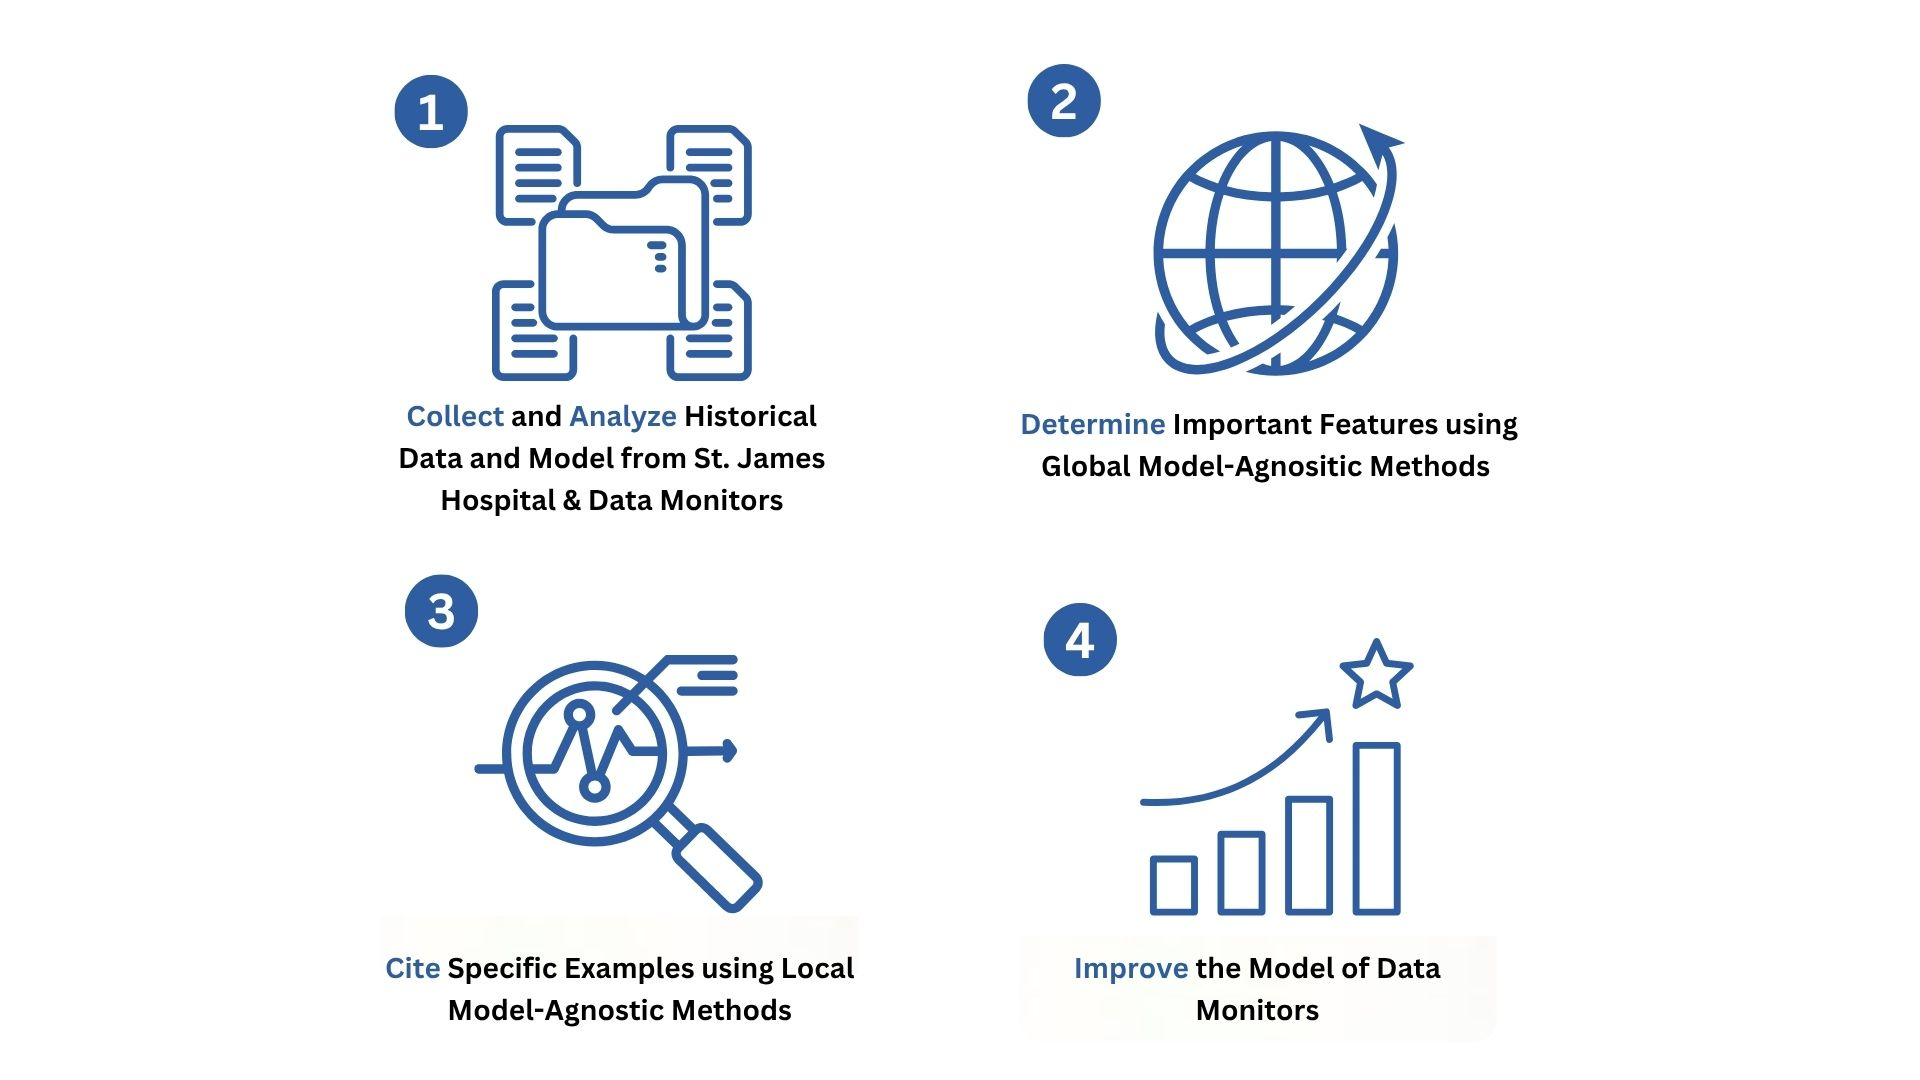


### **3.1 Collect and Analyze Historical Data from Data Monitors**
We first examined the historical dataset provided by St. James Hospital, exploring correlations between features and the target variable. 

### **3.2 Determine Important Features using Global Model-Agnositic Methods**
Global explainability methods were applied to assess feature importance across the entire dataset. Specifically, we used SHAP values, permutation feature importance, and model coefficients to identify which variables the model relied on most heavily when making predictions.

### **3.3 Cite Specific Examples using Local Model-Agnostic Methods**
Local explainability tools were employed to examine individual predictions. Anchors, ICE plots, and LIME were used to provide concrete examples of how the model made decisions for specific babies, highlighting potential blind spots and feature overreliance.

### **3.4 Improve the Model of Data Monitors**
To create a more reliable replacement, we tested multiple modeling approaches while experimenting with different strategies to handle class imbalance between the at-risk and healthy babies. Given the temporal nature of the data, we also incorporated time-series modeling using ARIMA to account for trends and patterns over time that could affect newborn outcomes.


---


# **4. Results and Discussion**

## 4.1 Collect and Analyze Historical Data from Data Monitors

We began by examining the historical dataset provided by Data Monitors to understand feature relationships and class distributions. A correlation matrix was constructed to assess how different variables relate to each other and to the target outcome. Two key insights emerged from this analysis. First, jaundice levels appeared to be a strong predictor of whether a newborn was at risk, as evident even from the histogram distributions (Figure 2). This is medically meaningful because elevated bilirubin levels, which cause jaundice, can indicate liver immaturity or hemolytic disorders in newborns, both of which increase the risk of complications if not managed promptly. 

## 4.2 Determine Important Features using Global Model-Agnositic Methods

Global explainability methods were applied to identify the features most influential in the model's predictions. SHAP values were used to aggregate individual feature contributions and provide a visual summary of the model’s overall behavior (Figure 3). This analysis revealed that jaundice level, followed by heart rate, were the most critical risk factors. High jaundice values strongly pushed predictions toward 'At Risk,' while low oxygen saturation and low birth weight also contributed to higher risk.

Feature importance was additionally used to verify that the logic of the model aligned with clinical knowledge (Figure 4). Jaundice emerged as the largest positive predictor, followed by heart rate, birth weight, and age, while lower values of oxygen and weight were associated with increased risk.


Although as seen in Figure 2, it makes sense to have jaundice as an important feature because of the clear dividing line it has. Further analysis indicated that the model was overreliant on this specific variable. We used permutation importance to quantify how much each feature affects the model's performance. Given the medical context, recall is a crucial metric because it directly measures the ability of the model to avoid False Negatives which has the highest cost since lives are at risk (Figure 5).  Jaundice caused an approximate 50 percent drop in recall when shuffled, whereas other features had much smaller effects. 


Partial Dependence Plots further corroborated this pattern (Figure 6), showing that as jaundice increased, predicted risk probability rose above 70 percent, while heart rate and oxygen saturation peaked at only 50 percent and 35 percent, respectively. Feature interaction analysis using Friedman’s H-statistic reinforced this finding, showing weak dependencies between jaundice and oxygen saturation (42 percent) and between jaundice and heart rate (34 percent). This indicates that jaundice acted mostly in isolation, explaining why the model focused on it so heavily.

## 4.3 Cite Specific Examples using Local Model-Agnostic Methods

Local explainability methods illustrated how the model made predictions for individual babies and provided concrete examples of patterns identified through global explainability. First, we used anchors to find a simple and clear rule. As shown in the table below, if a baby’s jaundice level is $\leq$ 4.30 mg/dL, the model predicts the baby to be healthy (class 0). Whenever this rule applies, the model from Data Monitors is always correct, which is why the precision is 1.0 and there are no misclassifications. The coverage of 0.75 means that this rule applies to about three-quarters of all babies, capturing the majority of cases. This shows that a single threshold explains much of the model’s behavior since low jaundice alone is enough for a confident healthy prediction. It also explains why the model relies so heavily on jaundice since it is still a strong and robust feature. However, this reliance becomes problematic when the model begins to overdepend on jaundice, as we will see with LIME and ICE.


The graphs of ICE reveals that jaundice level is the model's dominant feature, capable of driving the predicted risk probability to its maximum of 1.0 (100%) as the level increases. While high heart rate is also strongly correlated with risk, its maximum impact is limited to about 0.85 (85%); in contrast, oxygen saturation has a weaker, inverse relationship where risk peaks at only 0.45 (45%) at the lowest saturation value shown. This demonstrates a clear hierarchy in feature importance, with jaundice level being the critical factor that dictates the highest potential risk.


To show a concrete example of how the model overrelied on jaundice, we used LIME to compare two mostly similar babies. We manually reviewed the misclassified cases and identified the most similar babies, Nicole and Tara. Both had comparable heart rates, oxygen saturation levels, and weight with only minor differences in age in days and body temperature. The primary distinction between them was their jaundice level, with Nicole exhibiting a low jaundice level and Tara a high one. The model assigned a higher probability of being at risk to Tara (29%) and a lower probability to Nicole (9%), indicating that jaundice was the main factor influencing the model’s confidence in these predictions.


From both the perspectives of the global and local view, we see that jaundice is indeed clearly a strong predictor. However, the model relied on it too heavily, creating blind spots that were risky in practice.


## 4.4 Improve the model of Data Monitors

___

# **5. Conclusion and Recommendations** 

___

# **References**

Cheah, P. C. Y., Yang, Y., & Lee, B. G. (2023, September 5). Enhancing financial fraud detection 
through addressing class imbalance using Hybrid smote-gan techniques. MDPI. 
https://www.mdpi.com/2227-7072/11/3/110  

Federal Trade Commission. (2025, March 10). New FTC Data Show a Big Jump in Reported Losses to Fraud to $12.5 Billion in 2024. U.S. Federal Trade Commission. https://www.ftc.gov/news-events/news/press-releases/2025/03/new-ftc-data-show-big-jump-reported-losses-fraud-125-billion-2024

Vedešin, A. (2025). What Are Fraud Detection Rules: Types and Best Practices. Vespia. https://vespia.io/blog/fraud-detection-rules

Wainer, J. (2016). An empirical evaluation of imbalanced data strategies from a practitioner’s point of view (Technical Report 1606.00930). arXiv. Retrieved from https://arxiv.org/abs/1606.00930

Wang, Y. (2025, March 27). A data balancing and Ensemble Learning Approach for credit card 
fraud detection. arXiv.org. https://arxiv.org/abs/2503.21160 

---

# **Supplementary**


## Resampling Strategies

### Oversampling
- Duplicate or generate more minority samples.  
- **Pros:** Keeps all majority data  
- **Cons:** Risk of overfitting  

### Undersampling
- Drop some majority samples.  
- **Pros:** Fast, reduces dataset size  
- **Cons:** Lose information  

---

## Oversampling Techniques

### **SMOTE (Synthetic Minority Oversampling Technique)**
- Create new synthetic samples by interpolating neighbors.  
- Safer than just duplication.  
- **Variants:**
  - **SMOTETomek** = SMOTE + cleaning noisy points  
  - **SMOTEENN** = SMOTE + Edited Nearest Neighbors  
  - **ADASYN** = Adaptive sampling (harder examples get more samples)  

---

### **SMOTEN (Synthetic Minority Over-sampling Technique for Nominal features)**
- **Use case:** When you have **categorical features** (nominal, not ordinal).  
- **Problem:** Standard SMOTE interpolates between numeric features and cannot directly handle categories (e.g., *Red* vs *Blue*).  
- **How it works:**
  - For categorical features → picks the most frequent category among *k*-nearest neighbors.  
  - For numeric features → interpolates as in SMOTE.  
- **Advantage:** Works for **mixed data types** (numeric + categorical).  

---

### **SMOTE-NC (Synthetic Minority Over-sampling Technique for Nominal & Continuous features)**
- **Use case:** Datasets with **both categorical and continuous features**.  
- **Difference from SMOTEN:**
  - SMOTEN → categorical-only  
  - SMOTE-NC → hybrid datasets (categorical + continuous)  
- **How it works:**
  - Continuous features → interpolation  
  - Categorical features → nearest neighbor’s category is chosen (no interpolation)  
- **Advantage:** Can oversample in **mixed datasets** (e.g., fraud detection with `age [numeric]` and `transaction type [categorical]`).  

---

### **ADASYN (Adaptive Synthetic Sampling)**
- **Full name:** ADAptive SYNthetic Sampling  
- **Main idea:** Focuses on harder-to-learn cases near the decision boundary.  
- **How it works:**
  - Identify minority samples with many majority neighbors → “hard” examples.  
  - Generate more synthetic points around these hard examples.  
  - Easier minority samples → fewer synthetic samples.  
- **Advantage:** Creates a **more balanced decision boundary** → model learns rare but important cases.  
- **Disadvantage:** May introduce noise if misclassified points are oversampled too much.  

---

## When to Use Each

- **SMOTEN** → categorical-only datasets  
- **SMOTE-NC** → mixed categorical + continuous datasets  
- **ADASYN** → highly diverse minority examples, focusing on difficult boundary cases  


## **Details on Metrics**
1. Detection Rate
    * This asks, "Out of all transactions, how well does the model is at correctly identifying both fraud and non-fraud overall, where both are equally important?"

2. Fraud Capture Rate
    * This asks, "Out of all the fraud cases, how many did the model actually catch?"

3. Net Value Gained  - 
    * This asks, "How much money does the model helps save (by catching fraud)?"

1. **Detection Rate which is the same as Macro Recall**  
Detection Rate:  

$$
\text{Detection Rate} = \frac{1}{2} \bigg(\frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}} + \frac{TP_{\text{nonfraud}}}{TP_{\text{nonfraud}} + FN_{\text{nonfraud}}} \bigg)
$$

where  
- $n_{\text{fraud}}$ = number of fraud samples  
- $n_{\text{nonfraud}}$ = number of non-fraud samples  
- $N$ = total number of samples  
- $TP_{\text{fraud}}$ = fraud cases correctly identified  
- $FN_{\text{fraud}}$ = fraud cases missed  
- $TP_{\text{nonfraud}}$ = non-fraud cases correctly identified  
- $FN_{\text{nonfraud}}$ = non-fraud cases missed  


2. **Fraud Capture Rate, which is the same as Recall for Fraud Transactions**  

$$
\text{Fraud Capture Rate} = \frac{TP_{\text{fraud}}}{TP_{\text{fraud}} + FN_{\text{fraud}}}
$$  

where  
- $TP_{\text{fraud}}$ = fraud cases correctly identified  
- $FN_{\text{fraud}}$ = fraud cases missed  


3. **Net Value**  

$$
\text{Net Value} = V_{\text{caught}} - V_{\text{innocently flagged}}
$$  

where  
- $V_{\text{caught}}$ = total value of fraud correctly detected 
- $V_{\text{innocently flagged}}$ = total value of fraud incorrectly detected 